In [1]:
# function to solve B using non-negative least squares
from scipy.optimize import nnls
%cd ..
from compiler_options import compiler_decorator
from myutils import khatri_rao_power, khatri_rao_product, \
     option_parser, compiler_decorator, prange, pos, isbool, \
    dormqr, lapack, norm

from part_sym_SPM import spm_21sym

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.linalg import svd

import numpy as np
# the output of this cell is covid_T.npy
import anndata as ad
from sklearn.decomposition import PCA
import pandas as pd


def nnls_refine_B(T, A):
    """
    Refine B matrix using non-negative least squares.
    
    Parameters:
    -----------
    T : numpy.ndarray
        Original tensor (m × m × n)
    A : numpy.ndarray  
        A matrix from decomposition (m × r)
        
    Returns:
    --------
    B_nnls : numpy.ndarray
        Non-negative refined B matrix
    """
    m, _, n = T.shape
    r = A.shape[1]
    
    # Reshape tensor for matrix operations
    T_mat = T.reshape(m, -1)  # m × (m*n)
    
    # Compute Khatri-Rao product A ⊙ A
    A_kr = khatri_rao_power(A, 2)  # (m²) × r
    
    B_nnls = np.zeros((n, r))
    residual_list = []
    # Solve for each context (row of B) separately
    for i in range(n):
        # Extract the i-th slice: T[:,:,i]
        T_slice = T[:, :, i].flatten()  # Flatten to vector of length m²
        
        # Solve non-negative least squares: min ||A_kr * b_i - T_slice||²
        # subject to b_i >= 0
        b_i, residual = nnls(A_kr, T_slice)
        residual_list.append(residual)
        B_nnls[i, :] = b_i

    return B_nnls,residual_list

# A, B = spm_21sym(T_500,r)
# B_nnls, residual_list = nnls_refine_B(T_500.copy(), A)

/ewsc/exxact04/sbhate/mcpc/covid_code


In [2]:
metadata =pd.read_pickle('/data/sbhate/mcpc/ds_metadata.pkl')
embedding_info = pd.read_parquet('/data/sbhate/mcpc/human_sentences_with_embeddings.parquet')
embeddings = np.load('/data/sbhate/mcpc/human_embeddings.npy')
info = metadata.set_index('ds_index')[[2,'class']].loc[embedding_info['dataset_index'].values]
embedding_info['pub_year'] = info[2].values
embedding_info['class'] = info['class'].values
embedding_info['time'] = 'NONE'
T = 20
for i in range(1800,1900+T,T):
    embedding_info['time'].loc[(embedding_info['pub_year']>i) & (embedding_info['pub_year']<=i+T) ] = f'{i}-{i+T}'
    
embedding_info['context'] = embedding_info['class'] + '--'+ embedding_info['time']

/tmp/ipykernel_2160753/972442789.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  embedding_info['time'].loc[(embedding_info['pub_year']>i) & (embedding_info['pub_year']<=i+T) ] = f'{i}-{i+T}'
/tmp/ipykernel_2160753/972442789.py:10: Sett

In [3]:
x_sub = pd.DataFrame(embeddings)[embedding_info['time']!='NONE']
label = embedding_info['context'].loc[x_sub.index]
covs = x_sub.groupby(label).apply(lambda w : np.cov(w.T))
T_500 = np.stack(covs,axis = 2)

In [4]:
# choose 25 to be the rank
r = 10
np.random.seed(18)
A, B = spm_21sym(T_500,r)
B_nnls, residual_list= nnls_refine_B(T_500.copy(), A)

out = pd.DataFrame(B_nnls,index = covs.keys())

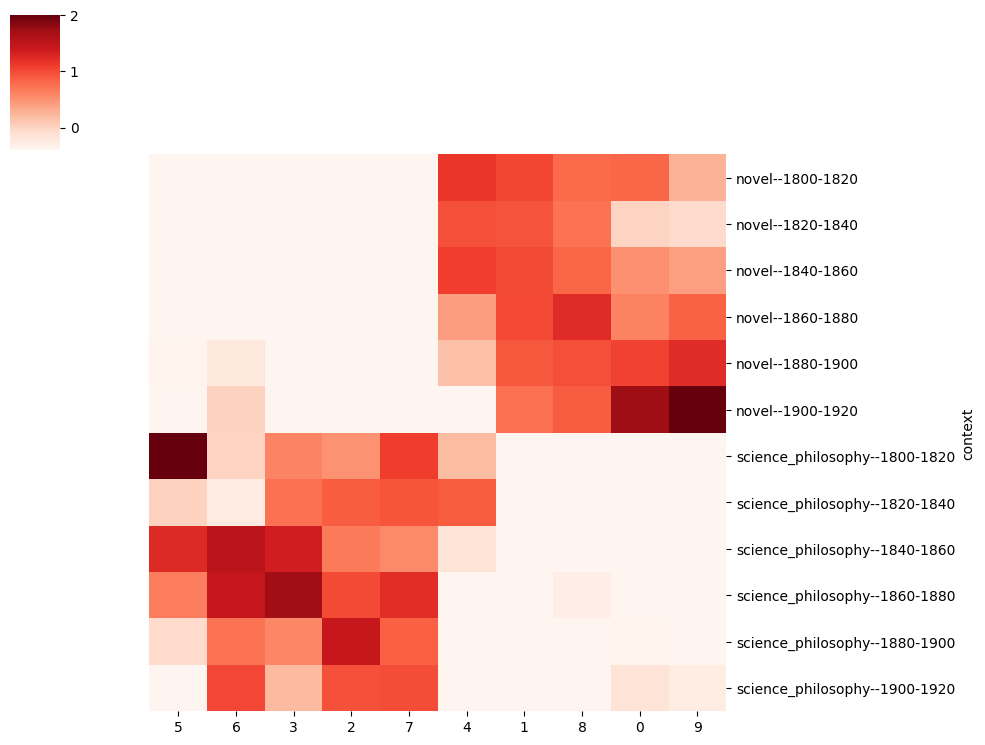

In [46]:


g = sns.clustermap(out.iloc[:,:50],cmap = 'Reds',z_score = 1, vmin = -0.4, vmax =2,figsize =( 10,7.5),xticklabels=True,yticklabels = True,metric = 'correlation',row_cluster = False)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)


In [32]:
form = [a.split('--')[0] for a in out.index]
year = [int(a.split('--')[1].split('-')[0])+10 for a in out.index]
plot_df= out.copy()
plot_df['form'] = form
plot_df['year'] = year
plot_df['timeframe'] = [a.split('--')[1] for a in out.index]

(1.0532476482087736, 1.7947477540825119)

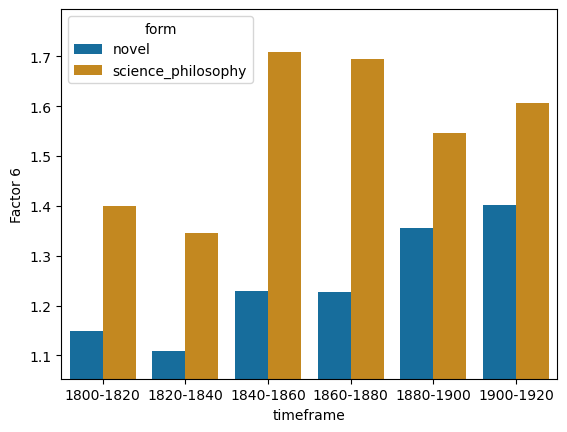

In [43]:
i = 6
sns.barplot(plot_df, x = 'timeframe', hue = 'form', y = i,palette = 'colorblind')
plt.ylabel(f'Factor {i}')
plt.ylim(0.95*plot_df[i].min(), 1.05*plot_df[i].max())

In [7]:
proj = np.linalg.pinv(A).T
loadings = pd.concat([embedding_info[['sentence','context','time','class']],metadata.set_index('ds_index')[[1,2]].rename({1:'name', 2:'year'},axis=1).loc[embedding_info['dataset_index']].reset_index(),pd.DataFrame((embeddings@proj))],axis=1)

In [8]:
pal = sns.color_palette('colorblind',2)

([<matplotlib.axis.XTick at 0x7f4b712619d0>,
 [Text(0, 0, '1800-1820'),
  Text(1, 0, '1820-1840'),
  Text(2, 0, '1840-1860'),
  Text(3, 0, '1860-1880'),
  Text(4, 0, '1880-1900'),
  Text(5, 0, '1900-1920')])

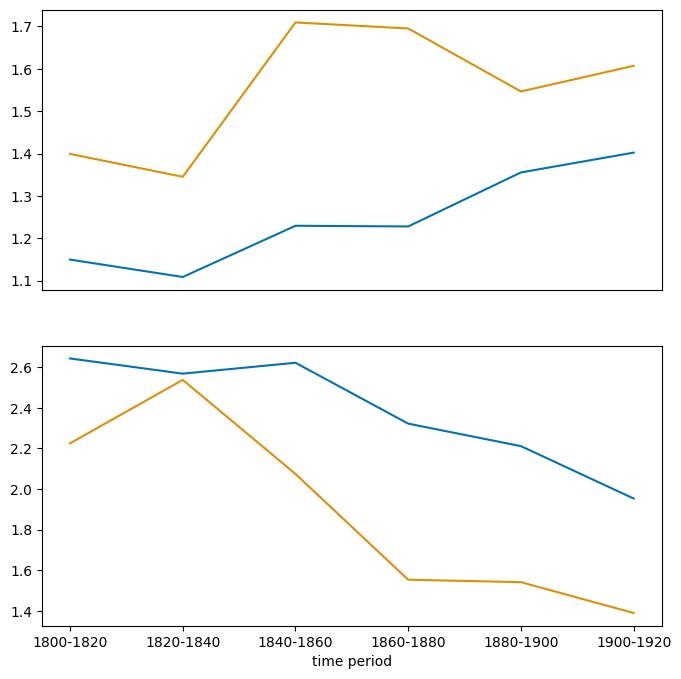

In [9]:
plt.figure(figsize= (8,8))
plt.subplot(2,1,1)
(out[6].filter(regex='novel')).plot(c = pal[0])
(out[6].filter(regex='sci')).plot(c = pal[1])
plt.xticks([]);
plt.xlabel('')
plt.subplot(2,1,2)
(out[4].filter(regex='novel')).plot(c = pal[0])
(out[4].filter(regex='sci')).plot(c = pal[1])
plt.xticks([]);
plt.xlabel('time period')
plt.xticks(range(6),loadings.groupby(['time','class'])[6].std().unstack().drop('NONE').index)
# plt.ylabel('normalized context loading')

In [18]:
b6 = loadings.groupby(['name','time','class'])[4].median().sort_values()
print(b6.iloc[-10:].to_csv(sep = '\t'))


name	time	class	4
Scientific American Supplement No. 648 June 2 1888 by Various	1880-1900	science_philosophy	3.943082981424146
The Fall of Prince Florestan of Monaco by Charles Wentworth Dilke	1860-1880	novel	3.9436892018881142
Mrs. Cliff's Yacht by Frank R. Stockton	1880-1900	novel	4.166099373550024
The King's Warrant by Alfred H. Engelbach	1860-1880	novel	4.296878378401406
The Justice and Necessity of Taxing the American Colonies	NONE	science_philosophy	4.30681758020028
Jack Archer by G. A. Henty	1880-1900	novel	4.383407491118222
The Loudwater Tragedy by T. W. Speight	1880-1900	novel	4.855047868131887
A Little Country Girl by Susan Coolidge	1880-1900	novel	5.042362363690798
The History of the Revolutions of Portugal by Abb Vertot	NONE	science_philosophy	5.227093705403142
Woman's Trials by T. S. Arthur	1840-1860	novel	5.950057220691049



/tmp/ipykernel_2640399/262311744.py:1: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data = loadings.groupby(['name','time','class'])[6].median().sort_values().reset_index(),


<Axes: xlabel='time', ylabel='6'>

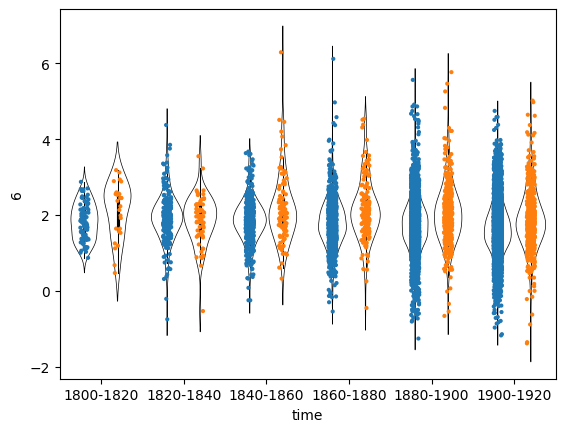

In [108]:
sns.violinplot(data = loadings.groupby(['name','time','class'])[6].median().sort_values().reset_index(),
              x = 'time',y = 6, hue = 'class',dodge = True,
              order =['1800-1820', '1820-1840', '1840-1860', '1860-1880', '1880-1900',
       '1900-1920'],legend=False,fill = None, palette = ['black'],linewidth =0.5,hue_order = ['novel', 'science_philosophy'])
sns.stripplot(data = loadings.groupby(['name','time','class'])[6].median().sort_values().reset_index(),
              x = 'time',y = 6, hue = 'class',dodge = True,
              order =['1800-1820', '1820-1840', '1840-1860', '1860-1880', '1880-1900',
       '1900-1920'], s = 3,hue_order = ['novel', 'science_philosophy'],legend = False)

In [103]:
loadings.groupby(['name','time','class'])[4].median().sort_values().filter(regex = 'science')

name                                                                 time       class             
Natural History by Anonymous                                         1820-1840  science_philosophy   -2.546655
Birds and All Nature Vol. III No. 3 March 1898 by Various            1880-1900  science_philosophy   -2.174357
Reincarnation by Swami Abhedananda                                   1900-1920  science_philosophy   -2.135503
The Cleveland Medical Gazette Vol. 1 No. 4 February 1886 by Various  1880-1900  science_philosophy   -2.074291
The Philosophy of Evolution by Stephen H. Carpenter                  1860-1880  science_philosophy   -2.012826
                                                                                                        ...   
Life and Treason of Benedict Arnold by Jared Sparks                  1820-1840  science_philosophy    3.461776
Memoirs Correspondence and Manuscripts of General Lafayette          1820-1840  science_philosophy    3.754560
Scientific Am

/tmp/ipykernel_2640399/3647719959.py:1: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data = loadings.groupby(['name','time','class'])[4].median().sort_values().reset_index(),


<Axes: xlabel='time', ylabel='4'>

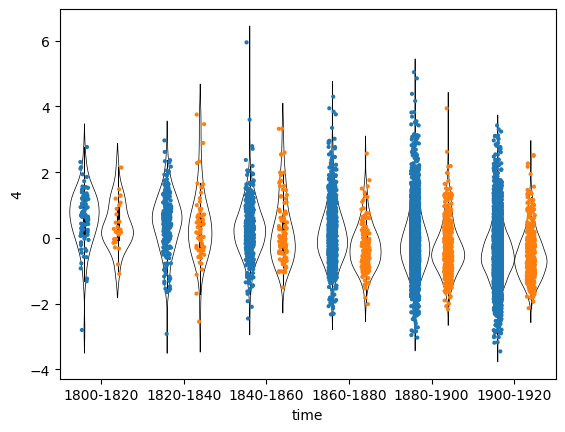

In [109]:
sns.violinplot(data = loadings.groupby(['name','time','class'])[4].median().sort_values().reset_index(),
              x = 'time',y = 4, hue = 'class',dodge = True,
              order =['1800-1820', '1820-1840', '1840-1860', '1860-1880', '1880-1900',
       '1900-1920'],legend=False,fill = None, palette = ['black'],linewidth =0.5)
sns.stripplot(data = loadings.groupby(['name','time','class'])[4].median().sort_values().reset_index(),
              x = 'time',y = 4, hue = 'class',dodge = True,
              order =['1800-1820', '1820-1840', '1840-1860', '1860-1880', '1880-1900',
       '1900-1920'], s = 3,legend = False)

In [121]:
pal = sns.color_palette('colorblind', 2)

In [21]:
topsen = loadings.sort_values(4)['sentence']
print('=== LOW ===')
print('\n---\n'.join(topsen[:10].tolist()))

print('=== HIGH ===')
print('\n---\n'.join(topsen[-10:].tolist()))
      
# print('high')
# print('\n---\n'.join(topsen[-10:][::-1]))
# print('\n---\n'.join([a for a in topsen[-40:] if 'uman nature' in a]))
# print('\n---\n'.join(topsen[-40:]))

=== LOW ===
We have a right to suppose that he created the earth intending to people it with human beings.
---
"Because of human nature.
---
They have the power to take the human form and leave it.
---
"Human nature!
---
He wants contact with human beings.
---
"I make him out human.
---
"It's human nature!
---
I’m thinking of human nature.
---
Those moments are bound to come, because you're human.
---
“Yes, human beings.
=== HIGH ===
BONAR To one of the most tender-hearted of human beings had the office of conveying ill tidings been most often committed, and again Dr. May found himself compelled to precede Henry Ward into the sister's presence, and to break to her the result of the inquest.
---
It says much for his resolutions of reform that, in spite of all, he spent several hours every day at chambers, trying to bend his mind to Benjamin on Sales and, by virtue of the human interest of that remarkable work, succeeding better than was to be expected.
---
It failed partly from mere ill

In [117]:
topsen = loadings.sort_values(4)['sentence']
# print('low')
# print('\n---\n'.join(topsen[:10]))
print('high')
print('\n---\n'.join(topsen[-10:][::-1]))
# print('\n---\n'.join([a for a in topsen[-40:] if 'uman nature' in a]))
# print('\n---\n'.join(topsen[-40:]))

high
A very great amount of permanent improvement in human affairs might be secured in this direction by the expenditure of a few thousand pounds in the systematic study of the most educational method of dealing with children in the first two or three years of life, and in the intelligent propagation of the knowledge obtained.
---
Philip Hayforth had certainly not more than an average share of human vanity, but he did at last suspect, partly from an accidental circumstance which had first drawn his attention to the subject, that he had created in the heart of the innocent Fanny a deeper interest than he had ever intended.
---
Strange human nature, too, would have it, that the doubts and apprehensions which had arisen in his mind should render him only the mere eager to overcome anything like coldness upon her part; and he strove, with soft speeches and low-toned words, to win her ear to himself alone.
---
Therefore in all human probability he would drive straight on till dark, no doubt

Text(0, 0.5, '')

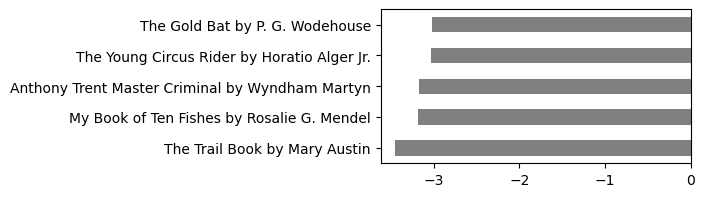

In [172]:
plt.figure(figsize = (4,2))
loadings[loadings['time']!='NONE'].groupby('name')[4].median().sort_values().iloc[:5].plot.barh(color = 'grey')
# plt.xlim(5.4,6.5)
plt.ylabel('')
# plt.xtic

Text(0, 0.5, '')

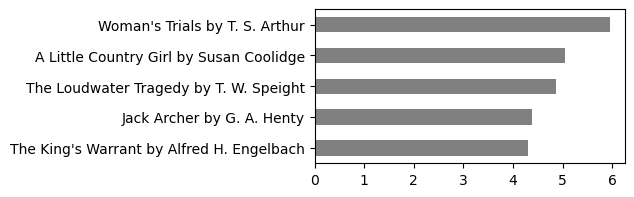

In [171]:
plt.figure(figsize = (4,2))
loadings[loadings['time']!='NONE'].groupby('name')[4].median().sort_values().iloc[-5:].plot.barh(color = 'grey')
# plt.xlim(5.4,6.5)
plt.ylabel('')
# plt.xtic

In [120]:
from sklearn.decomposition import PCA

pc_novel = PCA(n_components=50)
pc_science = PCA(n_components=50)
pc_all = PCA(n_components=50)
pc_novel.fit(x_sub[label.str.contains('novel')])
pc_science.fit(x_sub[label.str.contains('science')])
pc_all.fit(x_sub)

,n_components,50
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [122]:
proj = np.linalg.pinv(A).T
loadings = pd.concat([embedding_info[['sentence','context','time','class']],metadata.set_index('ds_index')[[1,2]].rename({1:'name', 2:'year'},axis=1).loc[embedding_info['dataset_index']].reset_index(),pd.DataFrame((embeddings@proj))],axis=1)
loadings_pc_all = pd.concat([embedding_info[['sentence','context','time','class']],metadata.set_index('ds_index')[[1,2]].rename({1:'name', 2:'year'},axis=1).loc[embedding_info['dataset_index']].reset_index(),pd.DataFrame((pc_all.transform(embeddings)))],axis=1)
loadings_pc_novel = pd.concat([embedding_info[['sentence','context','time','class']],metadata.set_index('ds_index')[[1,2]].rename({1:'name', 2:'year'},axis=1).loc[embedding_info['dataset_index']].reset_index(),pd.DataFrame((pc_novel.transform(embeddings)))],axis=1)
loadings_pc_sci = pd.concat([embedding_info[['sentence','context','time','class']],metadata.set_index('ds_index')[[1,2]].rename({1:'name', 2:'year'},axis=1).loc[embedding_info['dataset_index']].reset_index(),pd.DataFrame((pc_science.transform(embeddings)))],axis=1)

B_novel = pd.DataFrame(pc_novel.transform(x_sub),index = x_sub.index).groupby(label).std()
B_science = pd.DataFrame(pc_science.transform(x_sub),index = x_sub.index).groupby(label).std()
B_all = pd.DataFrame(pc_all.transform(x_sub),index = x_sub.index).groupby(label).std()




Text(0, 0.5, 'abs cosine similarity with A')

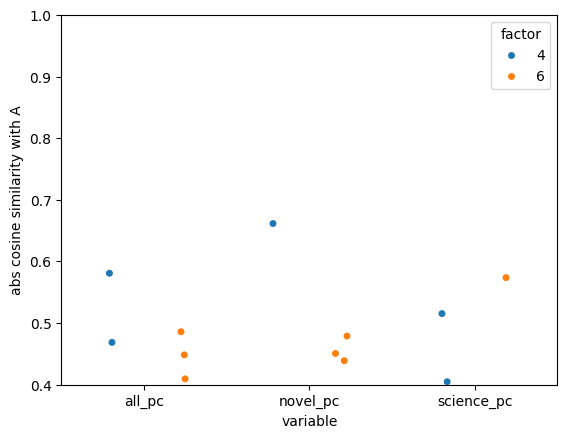

In [124]:
from scipy.spatial.distance import cdist
sns.stripplot(data = pd.concat([pd.DataFrame({'all_pc':np.abs(1-cdist(np.linalg.pinv(A),pc_all.components_,metric= 'cosine'))[4],
 'novel_pc':np.abs(1-cdist(np.linalg.pinv(A),pc_novel.components_,metric= 'cosine'))[4],
 'science_pc':np.abs(1-cdist(np.linalg.pinv(A),pc_science.components_,metric= 'cosine'))[4],
 'factor':'4'
 }),
 pd.DataFrame({'all_pc':np.abs(1-cdist(np.linalg.pinv(A),pc_all.components_,metric= 'cosine'))[6],
 'novel_pc':np.abs(1-cdist(np.linalg.pinv(A),pc_novel.components_,metric= 'cosine'))[6],
 'science_pc':np.abs(1-cdist(np.linalg.pinv(A),pc_science.components_,metric= 'cosine'))[6],
 'factor':'6'
 })
]).melt(id_vars = 'factor'),
x = 'variable',
hue = 'factor',
y = 'value',
dodge = True
)
plt.ylim(0.4, 1)
plt.ylabel('abs cosine similarity with A')


Text(0, 0.5, 'correlation with B')

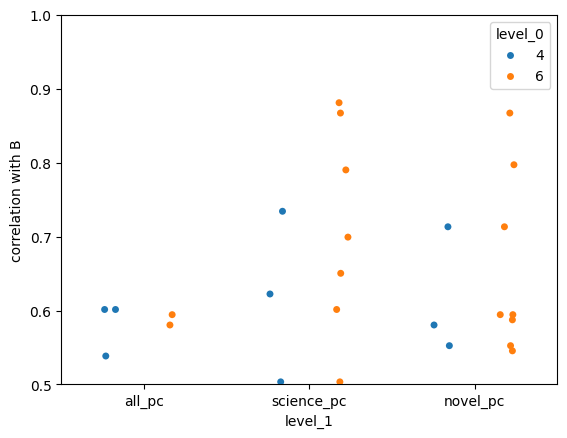

In [143]:
from scipy.stats import rankdata
mat_all = (1-cdist(rankdata(out,axis = 0).T, rankdata(B_all,axis = 0).T, metric = 'correlation'))
mat_novel = (1-cdist(rankdata(out,axis = 0).T, rankdata(B_novel,axis = 0).T, metric = 'correlation'))
mat_sci = (1-cdist(rankdata(out,axis = 0).T, rankdata(B_science,axis = 0).T, metric = 'correlation'))
dat = pd.concat({'all_pc': pd.DataFrame(mat_all),
           'science_pc': pd.DataFrame(mat_sci),
           'novel_pc':  pd.DataFrame(mat_novel)}).reorder_levels([1,0],axis=0).loc[[4,6]].melt(ignore_index=False).reset_index()

cor_dat = dat.copy()
dat['level_0'] = dat['level_0'].astype(str)
sns.stripplot(data = dat,
x = 'level_1',
hue = 'level_0',
y = 'value',
dodge = True
)
plt.ylim(0.5, 1)
plt.ylabel('correlation with B')

Text(0, 0.5, 'proportion of top entries covered')

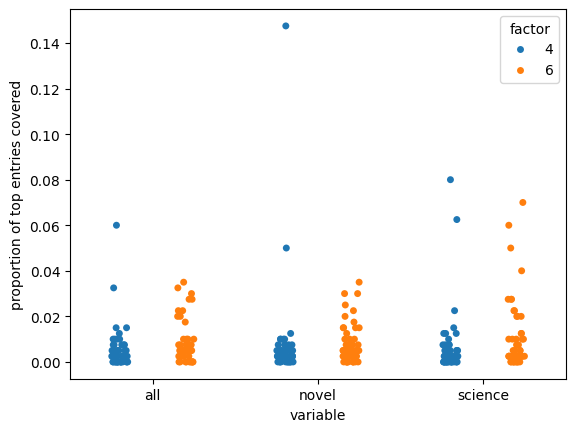

In [176]:
idxarr=np.concatenate([np.arange(200),np.arange(-200,0)])


tops = {}

for i,load in {'all':loadings_pc_all,'novel':loadings_pc_novel, 'sci': loadings_pc_sci}.items():
    tops[i] = np.argsort(load[range(50)].abs().values,axis=0)[idxarr]
    
top = loadings[4].sort_values().index[idxarr]
top4_int = pd.DataFrame({'all': (np.isin(tops['all'] ,top).mean(axis = 0)),
                         'novel': (np.isin(tops['novel'] ,top).mean(axis = 0)),
                         'science': (np.isin(tops['sci'] ,top).mean(axis = 0)),
                         'factor':'4'})

top = loadings[6].sort_values().index[idxarr]
top6_int = pd.DataFrame({'all': (np.isin(tops['all'] ,top).mean(axis = 0)),
                         'novel': (np.isin(tops['novel'] ,top).mean(axis = 0)),
                         'science': (np.isin(tops['sci'] ,top).mean(axis = 0)),
                         'factor':'6'})
            

covered_dat = pd.concat([top4_int,top6_int]).melt(id_vars = 'factor',ignore_index=False).reset_index()
sns.stripplot(data = pd.concat([top4_int,top6_int]).melt(id_vars = 'factor'),
              x = 'variable',
              y = 'value',
              hue = 'factor',
              dodge = True)

plt.ylabel('proportion of top entries covered')
           

In [186]:
cor_dat = cor_dat.rename({'level_0':'factor', 'variable':'index'},axis=1)
covered_dat['level_1'] = covered_dat['variable']+ '_pc'

In [213]:
covered_dat['level_1'] = covered_dat['level_1'].astype(str)
cor_dat['level_1'] = cor_dat['level_1'].astype(str)
cor_dat['factor'] = cor_dat['factor'].astype(str)

In [215]:
a = covered_dat.set_index(['level_1','factor','index']).rename({'value':'freq'},axis=1)['freq'].sort_index()
b = cor_dat.set_index(['level_1','factor','index']).rename({'value':'cor'},axis=1)['cor'].sort_index()

In [224]:
dat = pd.concat([a,b],axis=1).reset_index()

<Axes: xlabel='freq', ylabel='cor'>

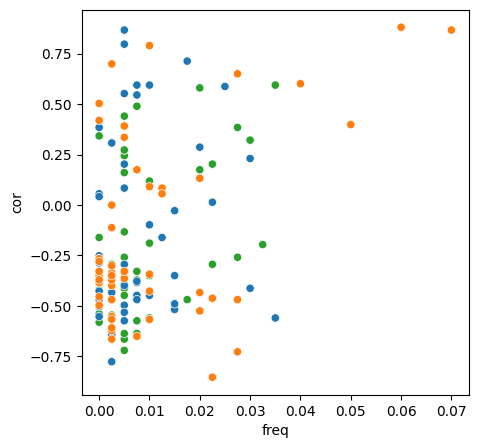

In [231]:
plt.figure(figsize = (5,5))
sns.scatterplot(data = dat[dat['factor']=='6'],
                x = 'freq', y = 'cor', hue = 'level_1',hue_order = ['novel_pc','science_pc','all_pc'],legend = False)

In [155]:
covered_dat = covered_dat.drop(['factor','variable'],axis=1).rename({'value':'freq'},axis=1)

In [167]:
covered_dat['level_0'] = covered_dat['level_0'].astype(int)